## REGIONES

Se encontraron 73 regiones individuales.

Objeto 1: Color promedio RGB [196 135  71] -> Detectado como: Rojizo/Naranja
Objeto 2: Color promedio RGB [87 39 16] -> Detectado como: Rojizo/Naranja
Objeto 3: Color promedio RGB [102  37  14] -> Detectado como: Rojizo/Naranja
Objeto 4: Color promedio RGB [87 40 14] -> Detectado como: Rojizo/Naranja
Objeto 5: Color promedio RGB [89 39 11] -> Detectado como: Rojizo/Naranja
Objeto 6: Color promedio RGB [86 39 15] -> Detectado como: Rojizo/Naranja
Objeto 7: Color promedio RGB [93 37 10] -> Detectado como: Rojizo/Naranja
Objeto 8: Color promedio RGB [113  41  13] -> Detectado como: Rojizo/Naranja
Objeto 9: Color promedio RGB [97 35 14] -> Detectado como: Rojizo/Naranja
Objeto 10: Color promedio RGB [90 38 14] -> Detectado como: Rojizo/Naranja
Objeto 11: Color promedio RGB [91 38 11] -> Detectado como: Rojizo/Naranja
Objeto 12: Color promedio RGB [95 36 13] -> Detectado como: Rojizo/Naranja
Objeto 13: Color promedio RGB [92 38 10] -> Detectado como

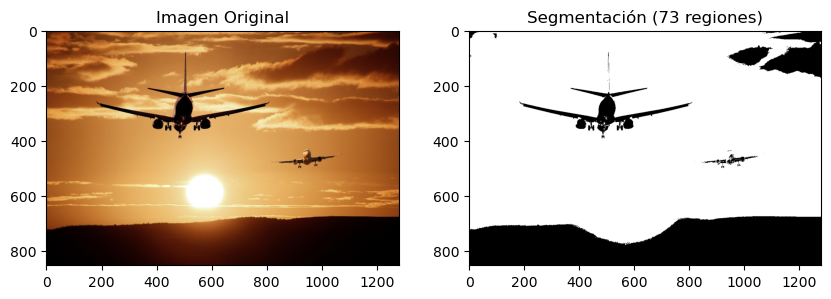

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def analizar_colores_por_region(imagen):

    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    _, binary = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    
    e_img = measure.label(binary, connectivity=2)
    num_objetos = np.max(e_img)
    
    
    img_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    
    resultados = []

   
    for i in range(1, num_objetos + 1):
        
        mask_objeto = (e_img == i)
        
       
        pixeles_objeto = img_rgb[mask_objeto]
        
       
        color_promedio = np.mean(pixeles_objeto, axis=0).astype(int)
        
        
        r, g, b = color_promedio
        etiqueta_color = "Indefinido"
        
        if r > g and r > b:
            etiqueta_color = "Rojizo/Naranja"
        elif g > r and g > b:
            etiqueta_color = "Verdoso"
        elif b > r and b > g:
            etiqueta_color = "Azulado"
            
        resultados.append({
            "id": i,
            "color_rgb": color_promedio,
            "clase": etiqueta_color
        })

    return num_objetos, resultados, binary

ruta = r'C:\pdi26\CLASE05052026\imagen1.jpg'  
img = cv2.imread(ruta)

if img is None:
    print("No se encontró la imagen.")
else:
    total, info_colores, binaria = analizar_colores_por_region(img)
    
    print(f"Se encontraron {total} regiones individuales.\n")
    
    for res in info_colores:
        print(f"Objeto {res['id']}: Color promedio RGB {res['color_rgb']} -> Detectado como: {res['clase']}")

    # Visualización
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Imagen Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    
    plt.subplot(1, 2, 2)
    plt.title(f"Segmentación ({total} regiones)")
    plt.imshow(binaria, cmap='gray')
    plt.show()

## 2

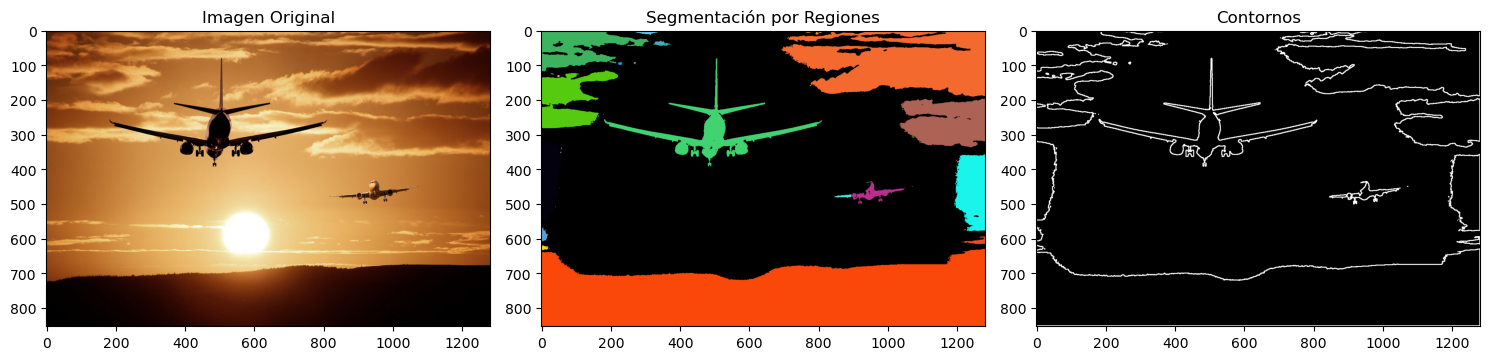

Totalll regiones 62

color 95, 179, 61 objetos 19489
color 234, 203, 92 objetos 924
color 3, 98, 243 objetos 12
color 14, 149, 245 objetos 420
color 46, 106, 244 objetos 76662
color 99, 187, 71 objetos 2
color 212, 153, 199 objetos 4
color 188, 174, 65 objetos 412
color 153, 20, 44 objetos 1
color 203, 152, 102 objetos 2
color 214, 240, 39 objetos 6
color 121, 24, 34 objetos 2
color 114, 210, 65 objetos 21590
color 239, 39, 214 objetos 2
color 244, 151, 25 objetos 79
color 74, 145, 222 objetos 27
color 14, 202, 85 objetos 19707
color 145, 117, 87 objetos 31
color 184, 189, 221 objetos 30
color 116, 237, 109 objetos 9
color 85, 99, 172 objetos 27115
color 226, 153, 103 objetos 1
color 235, 146, 36 objetos 6
color 151, 62, 68 objetos 3
color 181, 130, 160 objetos 2
color 160, 166, 149 objetos 4
color 6, 69, 5 objetos 3
color 52, 253, 112 objetos 16
color 14, 1, 3 objetos 10607
color 76, 248, 87 objetos 8
color 233, 212, 184 objetos 8
color 235, 245, 26 objetos 16007
color 213, 157, 253 o

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


imagen = 'imagen1.jpg'
img = cv2.imread(imagen)
if img is None:
    print("Error: No se pudo cargar la imagen.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

   
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    _, binary = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

   
    num_labels, labels = cv2.connectedComponents(binary)

    
    np.random.seed(42)
    colors = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
    colors[0] = [0, 0, 0]  
    colorear = colors[labels]

   
    contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contorno_fin = cv2.drawContours(np.zeros_like(img), contornos, -1, (255, 255, 255), 2)

 
    plt.figure(figsize=(15, 5))
    plt.subplot(131)
    plt.title("Imagen Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.subplot(132)
    plt.title("Segmentación por Regiones")
    plt.imshow(cv2.cvtColor(colorear, cv2.COLOR_BGR2RGB))

    plt.subplot(133)
    plt.title("Contornos")
    plt.imshow(cv2.cvtColor(contorno_fin, cv2.COLOR_BGR2RGB))
    plt.tight_layout()
    plt.show()

    
    print(f"Totalll regiones {num_labels - 1}")
    print()
    for lbl in range(1, num_labels):
        r, g, b = colors[lbl]
        count = int(np.sum(labels == lbl))
        print(f"color {r}, {g}, {b} objetos {count}")